<a href="https://colab.research.google.com/github/GayatriVidhate23/Machine--Vision-Practical/blob/main/MV_PRC_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CCTV.jpg to CCTV.jpg


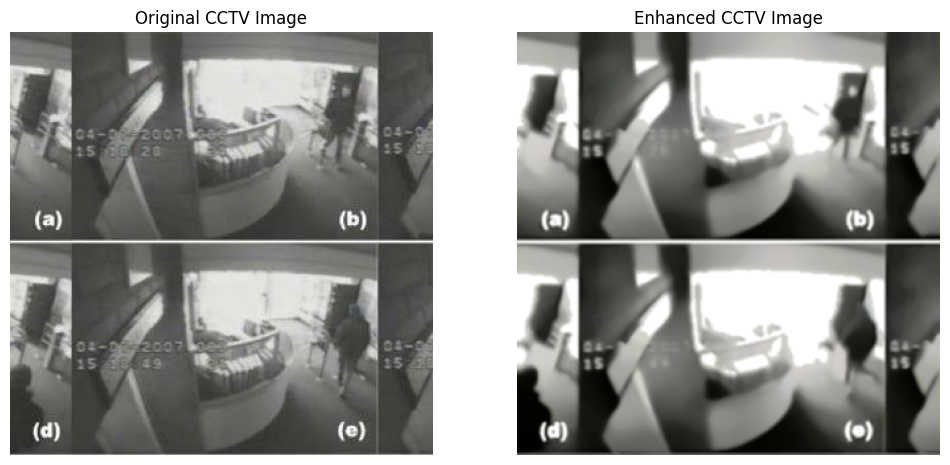

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read image
image = cv2.imread(list(uploaded.keys())[0])

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# -----------------------------
# 1. Noise Removal
# -----------------------------
denoised = cv2.fastNlMeansDenoisingColored(
    image, None, 10, 10, 7, 21
)

# -----------------------------
# 2. Brightness Enhancement
# -----------------------------
bright = cv2.convertScaleAbs(
    denoised,
    alpha=1.3,   # Contrast
    beta=40      # Brightness
)

# -----------------------------
# 3. Histogram Equalization
# -----------------------------
ycrcb = cv2.cvtColor(bright, cv2.COLOR_BGR2YCrCb)

# Equalize Y channel
ycrcb[:,:,0] = cv2.equalizeHist(ycrcb[:,:,0])

hist_eq = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

# -----------------------------
# 4. Gaussian Filtering
# -----------------------------
filtered = cv2.GaussianBlur(
    hist_eq,
    (3,3),
    0
)

# Convert to RGB
result_rgb = cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB)

# -----------------------------
# Display Results
# -----------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original CCTV Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result_rgb)
plt.title("Enhanced CCTV Image")
plt.axis("off")

plt.show()

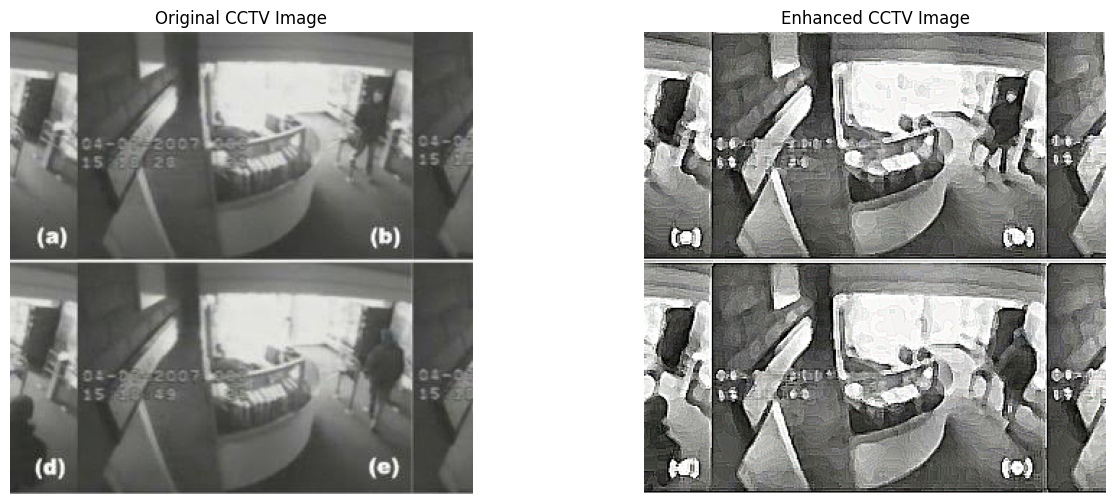

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read uploaded image
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)

# Convert BGR to RGB
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------
# 1. Noise Removal
# -------------------------
denoised = cv2.medianBlur(img, 5)

# -------------------------
# 2. Brightness Enhancement
# (Gamma Correction)
# -------------------------
gamma = 1.8
invGamma = 1.0 / gamma

table = np.array([
    ((i / 255.0) ** invGamma) * 255
    for i in np.arange(256)
]).astype("uint8")

gamma_corrected = cv2.LUT(denoised, table)

# -------------------------
# 3. CLAHE
# (Adaptive Histogram Equalization)
# -------------------------
lab = cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

cl = clahe.apply(l)

enhanced_lab = cv2.merge((cl, a, b))

enhanced = cv2.cvtColor(
    enhanced_lab,
    cv2.COLOR_LAB2BGR
)

# -------------------------
# 4. Sharpening Filter
# -------------------------
kernel = np.array([
    [-1,-1,-1],
    [-1, 9,-1],
    [-1,-1,-1]
])

sharpened = cv2.filter2D(
    enhanced,
    -1,
    kernel
)

# Convert for display
result = cv2.cvtColor(
    sharpened,
    cv2.COLOR_BGR2RGB
)

# -------------------------
# Display Images
# -------------------------
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original CCTV Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Enhanced CCTV Image")
plt.axis("off")

plt.show()